Downloading bucket files: 47086495 / 47086495 complete

Downloading bytes: 47086495 / 47086495 complete

Repacking RNA/artifacts/embedding//values: 1 / 1 complete

Repacking RNA/artifacts/connectivity_map//edges: 1 / 1 complete

Repacking RNA/artifacts/reduction//loadings: 1 / 1 complete

...

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

Loading kmeans coordinates: 1 / 1 complete

Training UMAP: 300 / 300 complete

Finding markers: 2 / 2 complete

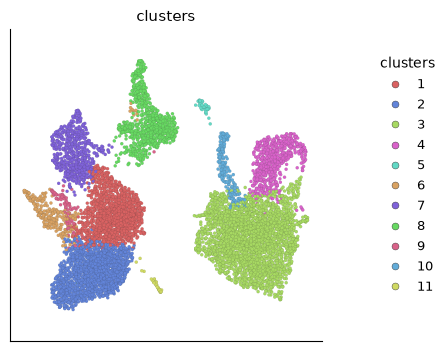

In [1]:
from pathlib import Path
from tempfile import TemporaryDirectory

import numpy as np
import pandas as pd

import scarf
from scarf.tools.repack_zarr import repack_store

scarf.configure_output(level="WARNING", progress=True)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "kang_15K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
analysis_directory = TemporaryDirectory()
counts_path = Path(analysis_directory.name) / "counts.zarr"
repack_store(f"{dataset}/data.zarr", str(counts_path), nthreads=2)
ds = scarf.mount_datastore(
    str(counts_path),
    at=str(Path(analysis_directory.name) / "analysis.zarr"),
    default_assay="RNA",
    nthreads=4,
)

run = ds.pipeline.run(
    filtering=False,
    cell_cycle=False,
    doublets=False,
)
ds.plots.embedding(run=run, layout="umap", color_by="clusters")

In [2]:
marker_ref = run["markers"]
cluster_values = np.asarray(run.cells.fetch("clusters"))
group_id = pd.Series(cluster_values).value_counts().index[0]
markers = ds.get_markers(
    marker=marker_ref,
    group_id=group_id,
    min_score=-1,
    min_frac_exp=-1,
)
markers[
    [
        "feature_name",
        "score",
        "frac_exp",
        "auc",
        "p_value",
        "p_value_adjusted",
    ]
].head()

,feature_name,score,frac_exp,auc,p_value,p_value_adjusted
0,SERPINB2,0.80485,0.19256,0.59529,9.690538e-247,1.709516e-244
1,CCL2,0.71465,0.51228,0.74451,0.000000e+00,0.000000e+00
2,S100A12,0.69539,0.26409,0.62937,0.000000e+00,0.000000e+00
3,CTB-61M7.2,0.68741,0.24783,0.61766,2.779526e-275,5.353968e-273
4,S100A8,0.67160,0.85405,0.91541,0.000000e+00,0.000000e+00


In [3]:
# Compare two clusters that are present in the Kang dataset.
result = ds.run_statistical_testing(
    ["MALAT1"],
    run["clusters"],
    groups=[1, 2],
    test="welch",
    alternative="greater",
)

# Pin retrieval to the exact immutable result returned by the run.
loaded = ds.get_statistical_tests(result.artifact)
loaded.tables["MALAT1"]

/home/parashar/scarf/scarf/datastore/_operations/features.py:3017: UserWarning: Cell-level statistical testing treats each cell as an independent observation. Results are descriptive distribution testing, not population-level condition or disease inference; this applies equally to explicitly requested parametric tests on single cells (welch, one_way_anova), which must survive zero-inflated, non-normal data. Aggregate cells to biological samples with sample_by for sample-level summary testing.
  outcomes[key_label] = compare_group_distributions(


,group_1,group_2,n_1,n_2,t_statistic,df,mean_1,mean_2,mean_difference,p_value,p_value_adjusted
0,1,2,1386,1650,-12.711213,2937.248709,69.220843,77.949775,-8.728932,1.0,1.0


In [4]:
# The plotted selection and test design must match the stored result.
figure = ds.plots.distribution(
    ["MALAT1"],
    grouping=run["clusters"],
    groups=[1, 2],
    kind="violin",
    stats_results=result.artifact,
    show=False,
)

In [5]:
group_sizes = (
    pd.Series(cluster_values, name="group")
    .astype(str)
    .value_counts()
    .sort_index()
)

In [6]:
bulk, fractions = ds.make_bulk(
    run["clusters"],
    from_assay="RNA",
    aggr_type="sum",
    feature_label="name",
    return_fraction=True,
)
totals = bulk.sum().rename("total_counts")
totals.index = totals.index.astype(str)
pd.concat([group_sizes.rename("n_cells"), totals], axis=1)

Aggregating pseudo-replicates: 11 / 11 complete

,n_cells,total_counts
1,1386,2078134
10,210,786527
11,32,111367
2,1650,2208962
3,2768,6914548
4,613,1773513
5,44,118662
6,253,429175
7,622,1019335
8,814,1332535


In [7]:
top_features = bulk.sum(axis=1).sort_values(ascending=False).head(8).index
bulk.loc[top_features], fractions.loc[top_features]

(             1       2        3       4     5      6      7      8     9  \
 FTH1     98830   42740  1044880  286750  3115   8611  22387  32275  4269   
 MALAT1  142331  170274   274954   95658  6672  28564  73253  86647  8720   
 FTL       4862    4554   568057   70781  4002   1669   2599   5669   438   
 B2M      59208   59450   192738   61703  2845   8867  39814  37373  4372   
 TMSB4X   79366   67975   132015   75014  2298   8456  39577  20531  5585   
 RPL10    27316   31896    36438    8593   829   3022  10018  15288  1451   
 TIMP1      646     310    94569   33027    12    138    228    185    93   
 RPS2     27279   30439    31877    8299   929   2841  10376  16562  1444   
 
            10    11  
 FTH1    60517  3421  
 MALAT1  34845  2998  
 FTL     21022  1102  
 B2M     22708  1262  
 TMSB4X  37358  1303  
 RPL10    5468   381  
 TIMP1    8588   332  
 RPS2     4822   440  ,
                1         2         3         4         5         6         7  \
 FTH1    0.99855

In [8]:
counts_csv = Path(analysis_directory.name) / "pseudobulk_counts.csv"
metadata_csv = Path(analysis_directory.name) / "pseudobulk_metadata.csv"

bulk.to_csv(counts_csv)
sample_metadata = pd.concat(
    [group_sizes.rename("n_cells"), totals],
    axis=1,
)
sample_metadata.index.name = "group"
sample_metadata.to_csv(metadata_csv)

pd.read_csv(counts_csv, index_col=0, nrows=5).iloc[:, :5]

,1,2,3,4,5
RP11-34P13.8,0,0,1,0,0
AL627309.1,1,1,0,0,0
RP11-206L10.2,0,1,1,0,0
RP11-206L10.9,0,0,2,0,0
FAM87B,0,0,0,2,0
